# Laboratorio 4: Análisis geoespacial de cianobacterias
## Avance - ejercicios 1 a 4

**Objetivo.** Analizar la señal de cianobacteria en los lagos de Amatitlán y Atitlán a partir de las 22 fechas oficiales Sentinel-2, con una cadena reproducible desde la descarga hasta el análisis temporal inicial.

**Fuentes.** Copernicus Data Space Ecosystem (Sentinel-2) y el script CyanoLakes Chlorophyll-a NDCI L1C de Sentinel Hub. Los ejercicios 5 a 8 se dejan explícitamente pendientes para la fase 2.

### 0. Dependencias

Las librerías utilizadas en este análisis están listadas en `requirements.txt`. La autenticación con Copernicus Data Space se realiza mediante OIDC y nunca se versionan credenciales. Abra Jupyter desde la raíz del proyecto para que las rutas relativas funcionen.

### Repositorio del proyecto

Código, historial de contribuciones e instrucciones de reproducción: [DS-LAB04 en GitHub](https://github.com/jcdiegolopez/DS-LAB04).

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    raise RuntimeError('Abra este notebook desde la carpeta raíz del proyecto DS-LAB04.')

sys.path.insert(0, str(PROJECT_ROOT / 'src'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from configuracion import LAKES, OFFICIAL_SCENES, REQUIRED_BANDS
from descarga import (
    build_inventory, connect_copernicus, download_official_scene,
    save_inventory, update_download_status, validate_geotiff,
)
import importlib
import indices
importlib.reload(indices)
from indices import CYANO_SCRIPT_NAME, CYANO_SCRIPT_URL, build_metrics_table, metrics_for_scene
import cianobacteria
importlib.reload(cianobacteria)
from cianobacteria import generate_cyano_scene
from analisis_temporal import detect_peaks, plot_cyano_timeseries, temporal_interpretation
from correlacion import correlation_table, plot_correlations
from analisis_espacial import (
    extent_and_persistence, high_value_threshold, load_lake_stack, monthly_summary,
    plot_comparison_maps, plot_distributions, plot_persistence,
    save_spatial_tables, select_comparison_dates,
)
from comparacion_lagos import build_lake_comparison, plot_lake_comparison, save_lake_comparison
from control_calidad import build_quality_checklist, save_quality_checklist

print(f'Bandas mínimas solicitadas: {REQUIRED_BANDS}')
print(f'Lagos configurados: {[item["display_name"] for item in LAKES.values()]}')

Bandas mínimas solicitadas: ('B03', 'B04', 'B08')
Lagos configurados: ['Lago de Amatitlán', 'Lago de Atitlán']


## 1. Conexión con la API Sentinel-2 (openEO)

La conexión a Copernicus Data Space permite consultar la colección Sentinel-2 L2A y generar las descargas necesarias para el análisis.

In [2]:
insumos_locales_completos = all(
    (PROJECT_ROOT / 'data' / 'raw' / lago / f'{lago}_{fecha}_B03_B04_B08.tif').exists()
    and (PROJECT_ROOT / 'data' / 'cyano' / lago / f'{lago}_{fecha}_cyano.tif').exists()
    for lago, escenas in OFFICIAL_SCENES.items()
    for fecha, *_ in escenas
)
if insumos_locales_completos:
    connection = None
    print('Se reutilizan los 22 pares de rasteres locales validados; no se requiere autenticación para esta ejecución.')
else:
    connection = connect_copernicus()
    print('Conexión autenticada:', connection)

Se reutilizan los 22 pares de rasteres locales validados; no se requiere autenticación para esta ejecución.


## 2. Obtención y trazabilidad de datos raster

El laboratorio exige trabajar únicamente con 11 fechas por lago. La validación siguiente debe dar exactamente 22 filas, 11 para Amatitlán y 11 para Atitlán.

In [3]:
inventory = build_inventory()
assert len(inventory) == 22, 'Deben existir 22 escenas oficiales en total.'
assert inventory.groupby('lago').size().to_dict() == {'amatitlan': 11, 'atitlan': 11}
save_inventory(inventory)
display(inventory)
print('Inventario actualizado.')

,lago,nombre_lago,fecha,satelite,nubosidad_oficial_pct,bandas_solicitadas,ruta_salida,estado_descarga,observaciones
0,amatitlan,Lago de Amatitlán,2025-01-28,Sentinel-2B,0.06,"B03,B04,B08",data/raw/amatitlan/amatitlan_2025-01-28_B03_B0...,pendiente,
1,amatitlan,Lago de Amatitlán,2025-04-15,Sentinel-2A,0.09,"B03,B04,B08",data/raw/amatitlan/amatitlan_2025-04-15_B03_B0...,pendiente,
2,amatitlan,Lago de Amatitlán,2025-04-28,Sentinel-2B,1.03,"B03,B04,B08",data/raw/amatitlan/amatitlan_2025-04-28_B03_B0...,pendiente,
3,amatitlan,Lago de Amatitlán,2025-11-24,Sentinel-2B,0.50,"B03,B04,B08",data/raw/amatitlan/amatitlan_2025-11-24_B03_B0...,pendiente,
4,amatitlan,Lago de Amatitlán,2026-01-08,Sentinel-2C,0.77,"B03,B04,B08",data/raw/amatitlan/amatitlan_2026-01-08_B03_B0...,pendiente,
5,amatitlan,Lago de Amatitlán,2026-02-02,Sentinel-2B,0.39,"B03,B04,B08",data/raw/amatitlan/amatitlan_2026-02-02_B03_B0...,pendiente,
6,amatitlan,Lago de Amatitlán,2026-02-07,Sentinel-2C,0.02,"B03,B04,B08",data/raw/amatitlan/amatitlan_2026-02-07_B03_B0...,pendiente,Cobertura válida parcial aproximada: 57.1%.
7,amatitlan,Lago de Amatitlán,2026-03-29,Sentinel-2C,0.01,"B03,B04,B08",data/raw/amatitlan/amatitlan_2026-03-29_B03_B0...,pendiente,
8,amatitlan,Lago de Amatitlán,2026-04-13,Sentinel-2B,0.09,"B03,B04,B08",data/raw/amatitlan/amatitlan_2026-04-13_B03_B0...,pendiente,
9,amatitlan,Lago de Amatitlán,2026-04-28,Sentinel-2C,4.96,"B03,B04,B08",data/raw/amatitlan/amatitlan_2026-04-28_B03_B0...,pendiente,


Inventario actualizado.


In [4]:
# Control de trazabilidad: fechas, satélite y nubosidad reportados en la guía.
display(inventory.groupby('lago', as_index=False).agg(
    imagenes=('fecha', 'count'),
    primera_fecha=('fecha', 'min'),
    ultima_fecha=('fecha', 'max'),
    nubosidad_promedio_reportada=('nubosidad_oficial_pct', 'mean'),
))

,lago,imagenes,primera_fecha,ultima_fecha,nubosidad_promedio_reportada
0,amatitlan,11,2025-01-28,2026-06-19,1.901818
1,atitlan,11,2025-01-18,2026-07-22,2.456364


### 2.1 Descarga mínima de una escena

La descarga se limita a B03, B04 y B08. Se valida una imagen de cada lago antes de procesar el conjunto completo. La fecha 2026-02-07 de Amatitlán cuenta con cobertura válida parcial (aprox. 57.1%), observación que se mantiene en el inventario.

In [5]:
atitlan_test = download_official_scene(connection, 'atitlan', '2025-01-18')
amatitlan_test = download_official_scene(connection, 'amatitlan', '2025-01-28')
display(pd.DataFrame([validate_geotiff(atitlan_test), validate_geotiff(amatitlan_test)]))

,ruta,bandas,crs,ancho,alto,resolucion,nodata
0,data/raw/atitlan/atitlan_2025-01-18_B03_B04_B0...,3,EPSG:32615,2759,1751,"(10.0, 10.0)",-32768.0
1,data/raw/amatitlan/amatitlan_2025-01-28_B03_B0...,3,EPSG:32615,1360,917,"(10.0, 10.0)",-32768.0


In [6]:

for row in inventory.itertuples(index=False):
    download_official_scene(connection, row.lago, row.fecha)
print('Verificación de escenas completada.')

Verificación de escenas completada.


### 2.2 Control de calidad de las descargas

El inventario registra el estado `descargado_validado` cuando el archivo es georreferenciado y contiene las tres bandas solicitadas.

In [7]:
inventory_final = update_download_status(inventory)
save_inventory(inventory_final)
display(inventory_final[['lago', 'fecha', 'satelite', 'bandas_solicitadas', 'estado_descarga', 'observaciones']])

pendientes = inventory_final.query("estado_descarga != 'descargado_validado'")
print(f'Escenas validadas: {(inventory_final.estado_descarga == "descargado_validado").sum()} de {len(inventory_final)}')
if not pendientes.empty:
    print('Pendientes o con incidencias:')
    display(pendientes[['lago', 'fecha', 'estado_descarga', 'observaciones']])

lista_calidad = build_quality_checklist(inventory_final)
save_quality_checklist(lista_calidad)
display(lista_calidad)
print('Control de calidad actualizado.')

,lago,fecha,satelite,bandas_solicitadas,estado_descarga,observaciones
0,amatitlan,2025-01-28,Sentinel-2B,"B03,B04,B08",descargado_validado,
1,amatitlan,2025-04-15,Sentinel-2A,"B03,B04,B08",descargado_validado,
2,amatitlan,2025-04-28,Sentinel-2B,"B03,B04,B08",descargado_validado,
3,amatitlan,2025-11-24,Sentinel-2B,"B03,B04,B08",descargado_validado,
4,amatitlan,2026-01-08,Sentinel-2C,"B03,B04,B08",descargado_validado,
5,amatitlan,2026-02-02,Sentinel-2B,"B03,B04,B08",descargado_validado,
6,amatitlan,2026-02-07,Sentinel-2C,"B03,B04,B08",descargado_validado,Cobertura válida parcial aproximada: 57.1%.
7,amatitlan,2026-03-29,Sentinel-2C,"B03,B04,B08",descargado_validado,
8,amatitlan,2026-04-13,Sentinel-2B,"B03,B04,B08",descargado_validado,
9,amatitlan,2026-04-28,Sentinel-2C,"B03,B04,B08",descargado_validado,


Escenas validadas: 22 de 22


,criterio,estado,evidencia,accion_requerida
0,Se usan exactamente las 22 fechas oficiales,cumple,Inventario: 22 filas; distribución por lago: {...,
1,"Rasteres B03, B04 y B08 disponibles",cumple,Rasteres encontrados: 22 de 22.,
2,Producto numérico de cianobacteria disponible,cumple,Rasteres numéricos encontrados: 22 de 22. Prod...,
3,Tabla de métricas por lago y fecha,cumple,Ruta esperada: outputs/tablas/metricas_por_fec...,


Control de calidad actualizado.


## 3. Producto numérico de cianobacteria

Se reproduce la formulación CyanoLakes Chlorophyll-a NDCI de Kravitz y Matthews (2020) con bandas Sentinel-2 L2A. Para cada fecha se genera un GeoTIFF numérico de una banda, con el valor de clorofila-a estimado en los píxeles de agua.

El producto final se guarda en `data/cyano/<lago>/` y se usa junto con NDVI y NDWI en las métricas temporales.

In [8]:
for row in inventory_final.itertuples(index=False):
    generate_cyano_scene(connection, row.lago, row.fecha)
print('Productos numéricos de cianobacteria verificados.')

Productos numéricos de cianobacteria verificados.


## 3. Índices espectrales

Se calculan NDVI = (B08 − B04) / (B08 + B04) y NDWI = (B03 − B08) / (B03 + B08). Las divisiones por cero, nodata y píxeles fuera de una máscara del lago se convierten en `NaN`.

La señal de cianobacteria se estima con **CyanoLakes Chlorophyll-a NDCI L1C (Kravitz & Matthews, 2020)**, documentado en el [Cyano Detection Script de Sentinel Hub](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/cyanobacteria_chla_ndci_l1c/). El visualizador por defecto del script produce colores RGB; para promedios, mapas y picos se necesita además una exportación **numérica** que conserve la fórmula, las máscaras y la grilla. El producto se guarda como `data/cyano/<lago>/<lago>_<fecha>_cyano.tif` y debe tener una banda alineada al raster mínimo.

Los cálculos convierten nodata, divisiones inválidas y píxeles fuera de la máscara en `NaN`. Mientras no se incorpore el GeoJSON de cada lago, la máscara solo excluye nodata; los resultados deben considerarse preliminares.

In [9]:
insumos_listos = (lista_calidad.iloc[:3]['estado'] == 'cumple').all()
if insumos_listos:
    metricas = build_metrics_table(inventory_final)
    display(metricas)
    print('Métricas e incidencias actualizadas.')
else:
    metricas = None
    print('No se calcularon métricas: complete los elementos pendientes de la lista de control antes de interpretar resultados.')

,lago,fecha,pixeles_validos,cobertura_valida_pct,mascara_lago_aplicada,cianobacteria_promedio,cianobacteria_mediana,cianobacteria_desviacion,ndvi_promedio,ndvi_mediana,ndvi_desviacion,ndwi_promedio,ndwi_mediana,ndwi_desviacion,incidencia
0,amatitlan,2025-01-28,104762,8.400314,False,14.139633,12.023779,8.540391,-0.333648,-0.323308,0.140063,0.577193,0.570093,0.106722,
1,amatitlan,2025-04-15,48363,3.877975,False,10.094927,4.817137,8.901563,-0.110013,-0.141058,0.112917,0.332597,0.339806,0.093446,
2,amatitlan,2025-04-28,92362,7.406023,False,13.328803,4.923873,15.788143,-0.082253,-0.146465,0.175418,0.329243,0.370583,0.165021,
3,amatitlan,2025-11-24,114263,9.162150,False,13.280656,6.940281,17.331558,-0.344771,-0.379630,0.229329,0.509513,0.523404,0.181067,
4,amatitlan,2026-01-08,123144,9.874270,False,22.571541,16.110493,19.234667,-0.089045,-0.125581,0.218190,0.368162,0.408451,0.200185,
5,amatitlan,2026-02-02,9620,0.771377,False,6.734544,6.500611,1.780095,-0.188640,-0.197917,0.062424,0.341192,0.338809,0.058846,
6,amatitlan,2026-02-07,39998,3.207229,False,7.854831,6.982613,3.473117,-0.217449,-0.219512,0.080108,0.433502,0.427451,0.084656,Cobertura válida parcial aproximada: 57.1%.
7,amatitlan,2026-03-29,89925,7.210613,False,17.142580,11.511004,15.406862,-0.064217,-0.083551,0.119371,0.321905,0.333333,0.117156,
8,amatitlan,2026-04-13,137174,10.999262,False,16.553223,14.043819,9.474962,-0.028497,-0.031332,0.053312,0.287160,0.289702,0.064230,
9,amatitlan,2026-04-28,131987,10.583344,False,24.164816,12.594663,24.736923,0.013476,0.011236,0.251528,0.287405,0.264069,0.245531,


Métricas e incidencias actualizadas.


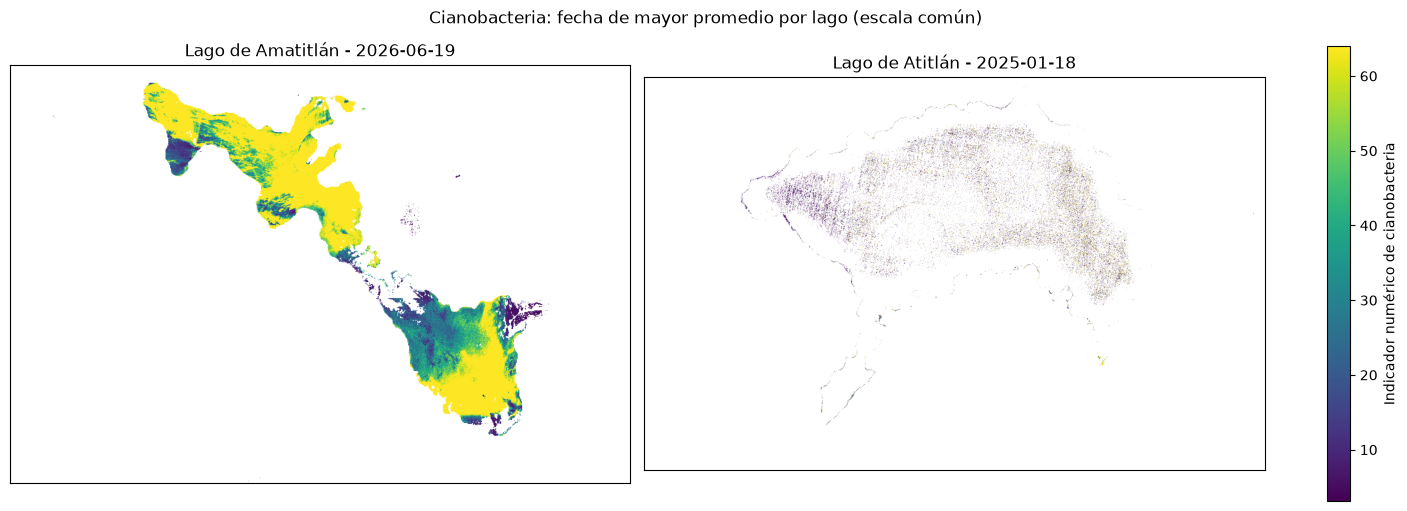

In [10]:
if metricas is not None:
    vmin = metricas['cianobacteria_promedio'].min()
    vmax = metricas['cianobacteria_promedio'].max()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    for ax, (lago, grupo) in zip(axes, metricas.groupby('lago')):
        escena = grupo.loc[grupo['cianobacteria_promedio'].idxmax()]
        _, capas = metrics_for_scene(lago, escena['fecha'])
        imagen = capas['cianobacteria'].copy()
        imagen[~capas['valid_mask']] = np.nan
        mapa = ax.imshow(imagen, cmap='viridis', vmin=vmin, vmax=vmax)
        ax.set(title=f"{LAKES[lago]['display_name']} - {escena['fecha']}", xticks=[], yticks=[])
    fig.colorbar(mapa, ax=axes, label='Indicador numérico de cianobacteria')
    fig.suptitle('Cianobacteria: fecha de mayor promedio por lago (escala común)')
    plt.show()
else:
    print('Mapa pendiente: aún no hay métricas verificables.')

## 4. Análisis temporal

Se usa como fecha crítica un **máximo local** cuyo promedio de cianobacteria es igual o superior al **percentil 75 de su propio lago**. El criterio se calcula por separado para no confundir las escalas y condiciones de Amatitlán y Atitlán.

,lago,fecha,pixeles_validos,cobertura_valida_pct,cianobacteria_promedio,umbral_percentil_75,es_pico,incidencia
0,amatitlan,2025-01-28,104762,8.400314,14.139633,19.857060,False,
1,amatitlan,2025-04-15,48363,3.877975,10.094927,19.857060,False,
2,amatitlan,2025-04-28,92362,7.406023,13.328803,19.857060,False,
3,amatitlan,2025-11-24,114263,9.162150,13.280656,19.857060,False,
4,amatitlan,2026-01-08,123144,9.874270,22.571541,19.857060,True,
5,amatitlan,2026-02-02,9620,0.771377,6.734544,19.857060,False,
6,amatitlan,2026-02-07,39998,3.207229,7.854831,19.857060,False,Cobertura válida parcial aproximada: 57.1%.
7,amatitlan,2026-03-29,89925,7.210613,17.142580,19.857060,False,
8,amatitlan,2026-04-13,137174,10.999262,16.553223,19.857060,False,
9,amatitlan,2026-04-28,131987,10.583344,24.164816,19.857060,False,


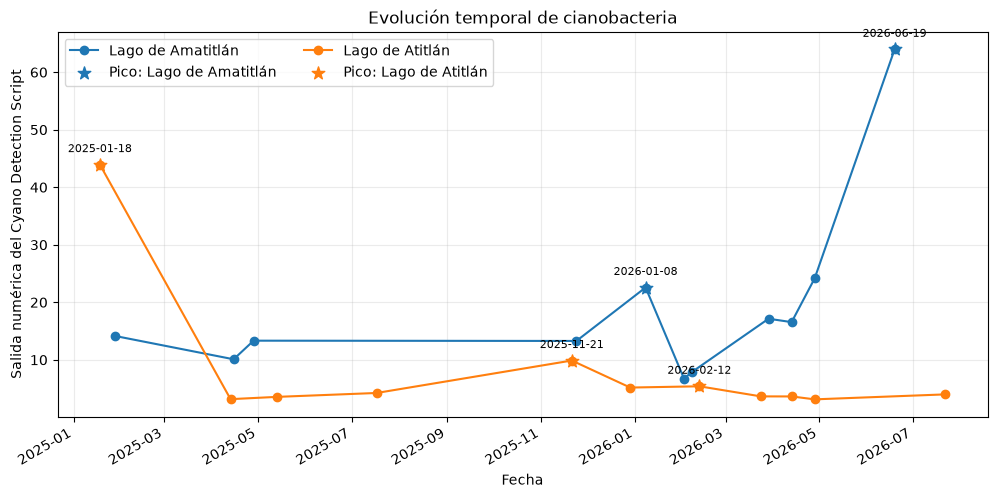

,lago,fecha_maxima,valor_maximo,numero_picos,interpretacion
0,amatitlan,2026-06-19,63.971619,2,La fecha máxima describe la señal del índice; ...
1,atitlan,2025-01-18,43.934631,3,La fecha máxima describe la señal del índice; ...


In [11]:
if metricas is not None:
    serie_temporal = detect_peaks(metricas)
    display(serie_temporal[['lago', 'fecha', 'pixeles_validos', 'cobertura_valida_pct', 'cianobacteria_promedio', 'umbral_percentil_75', 'es_pico', 'incidencia']])

    ax = plot_cyano_timeseries(serie_temporal)
    plt.show()

    resumen_temporal = temporal_interpretation(serie_temporal)
    display(resumen_temporal)
else:
    serie_temporal = None
    print('Análisis temporal pendiente: aún no hay métricas verificables.')

### Interpretación temporal inicial

La gráfica se lee de izquierda a derecha: cada punto es el promedio de píxeles válidos de una fecha oficial y las estrellas identifican fechas críticas. La tabla `resumen_temporal` reporta el máximo observado y el número de picos por lago. Esos son **hechos extraídos de los datos**. Lluvia, viento, temperatura, aportes de nutrientes y mezcla del agua son hipótesis que podrían explicar cambios, pero solo deben afirmarse tras contrastarlas con datos auxiliares; además, nubes, cobertura parcial o ausencia de máscara pueden alterar un promedio.

## 6. Correlaciones entre cianobacteria, NDVI y NDWI

La unidad de análisis es lago-fecha: cada fila resume los píxeles válidos de una escena. Con 11 fechas por lago, estas correlaciones son exploratorias y no demuestran causalidad.

,lago,relacion,predictor,n_fechas,pearson_r,pearson_p,spearman_rho,spearman_p,interpretacion
0,amatitlan,cianobacteria_vs_ndvi,ndvi_promedio,11,0.262732,0.435078,0.527273,0.095565,Relación positiva débil; no implica causalidad.
1,amatitlan,cianobacteria_vs_ndwi,ndwi_promedio,11,0.252956,0.452968,-0.181818,0.592615,Relación positiva débil; no implica causalidad.
2,atitlan,cianobacteria_vs_ndvi,ndvi_promedio,11,0.952126,0.000006,0.772727,0.005299,Relación positiva fuerte; no implica causalidad.
3,atitlan,cianobacteria_vs_ndwi,ndwi_promedio,11,0.723499,0.011848,0.936364,0.000022,Relación positiva fuerte; no implica causalidad.


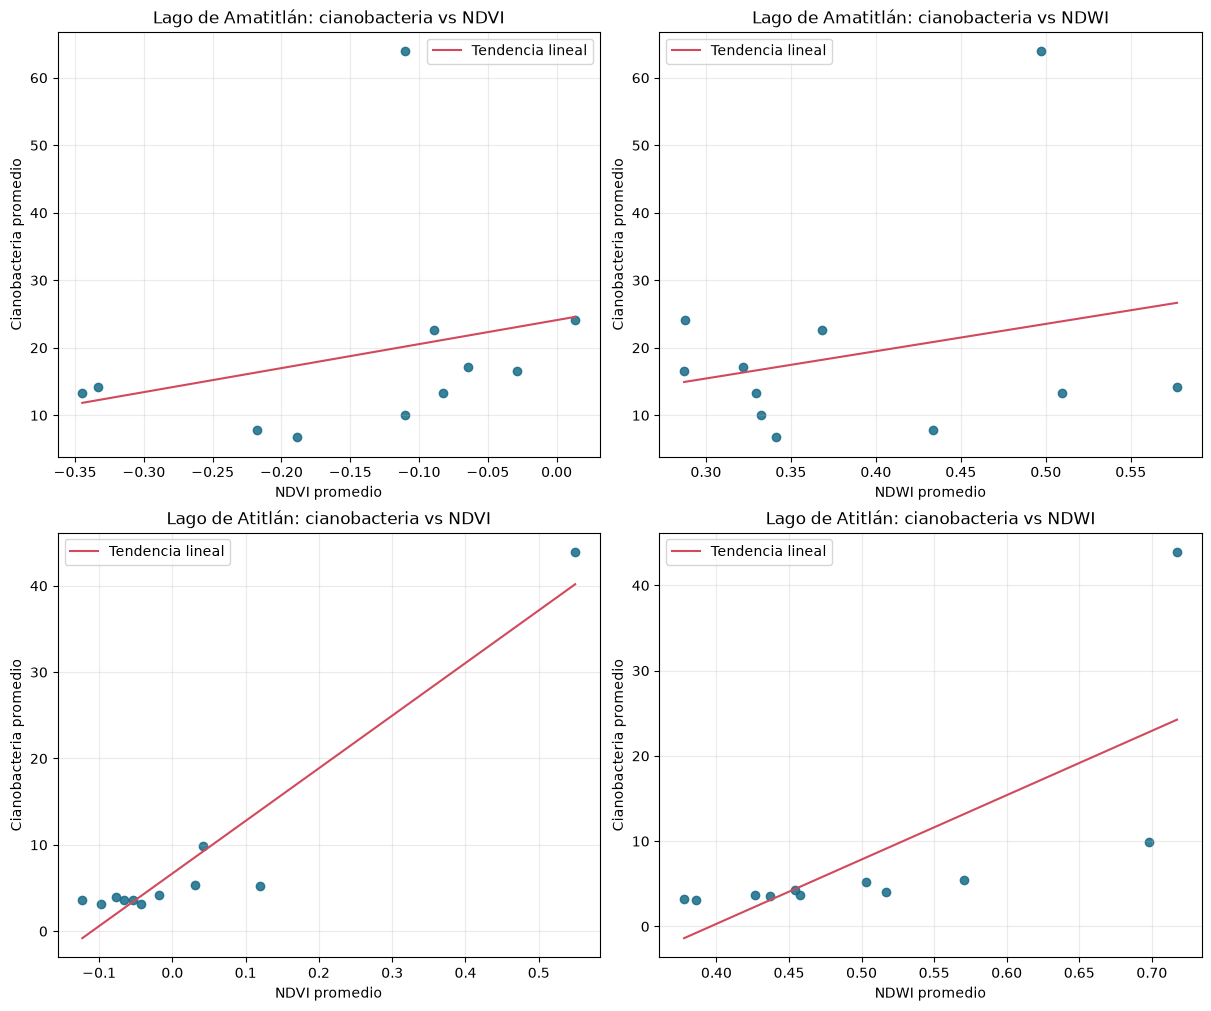

In [12]:
correlaciones = correlation_table(metricas)
display(correlaciones)
fig_correlaciones = plot_correlations(metricas)
Path('outputs/figuras').mkdir(parents=True, exist_ok=True)
fig_correlaciones.savefig('outputs/figuras/correlaciones_por_lago.png', dpi=180, bbox_inches='tight')
plt.show()

## 5. Análisis espacial de la cianobacteria

Se seleccionan fechas baja, intermedia y pico usando el promedio de la tabla maestra. La comparación usa una escala común y el mismo umbral global para ambos lagos.

Umbral alto reproducible (percentil 90 global): 10.27 µg/L


,categoria_comparacion,fecha,cianobacteria_promedio
5,baja,2026-02-02,6.734544
0,intermedia,2025-01-28,14.139633
10,pico,2026-06-19,63.971619


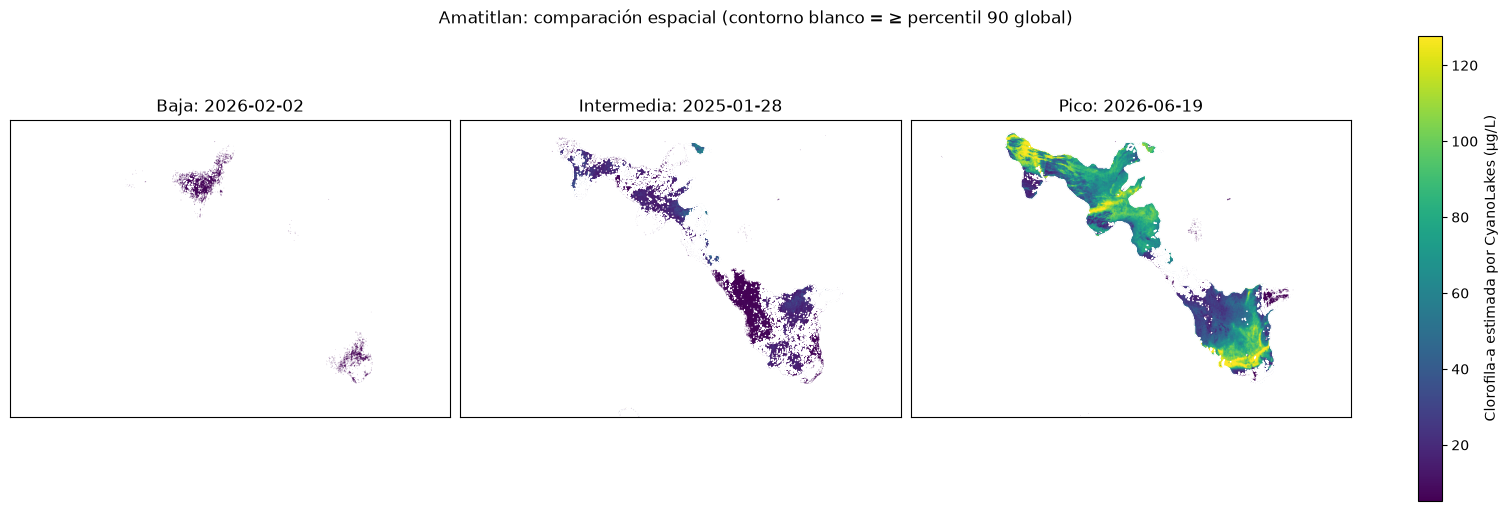

,lago,fecha,umbral_alto,pixeles_validos,pixeles_altos,porcentaje_area_alta
0,amatitlan,2025-01-28,10.26716,104762,65077,62.118898
1,amatitlan,2025-04-15,10.26716,48363,16286,33.674503
2,amatitlan,2025-04-28,10.26716,92362,29376,31.805288
3,amatitlan,2025-11-24,10.26716,114263,35427,31.004787
4,amatitlan,2026-01-08,10.26716,123144,98176,79.724550
5,amatitlan,2026-02-02,10.26716,9620,365,3.794179
6,amatitlan,2026-02-07,10.26716,39998,5553,13.883194
7,amatitlan,2026-03-29,10.26716,89925,51467,57.233250
8,amatitlan,2026-04-13,10.26716,137174,109194,79.602549
9,amatitlan,2026-04-28,10.26716,131987,68190,51.664179


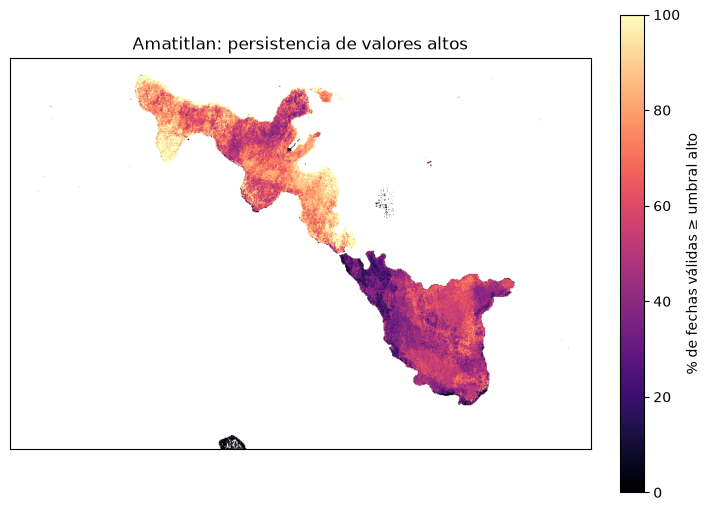

,categoria_comparacion,fecha,cianobacteria_promedio
20,baja,2026-04-28,3.127238
21,intermedia,2026-07-22,3.992429
11,pico,2025-01-18,43.934631


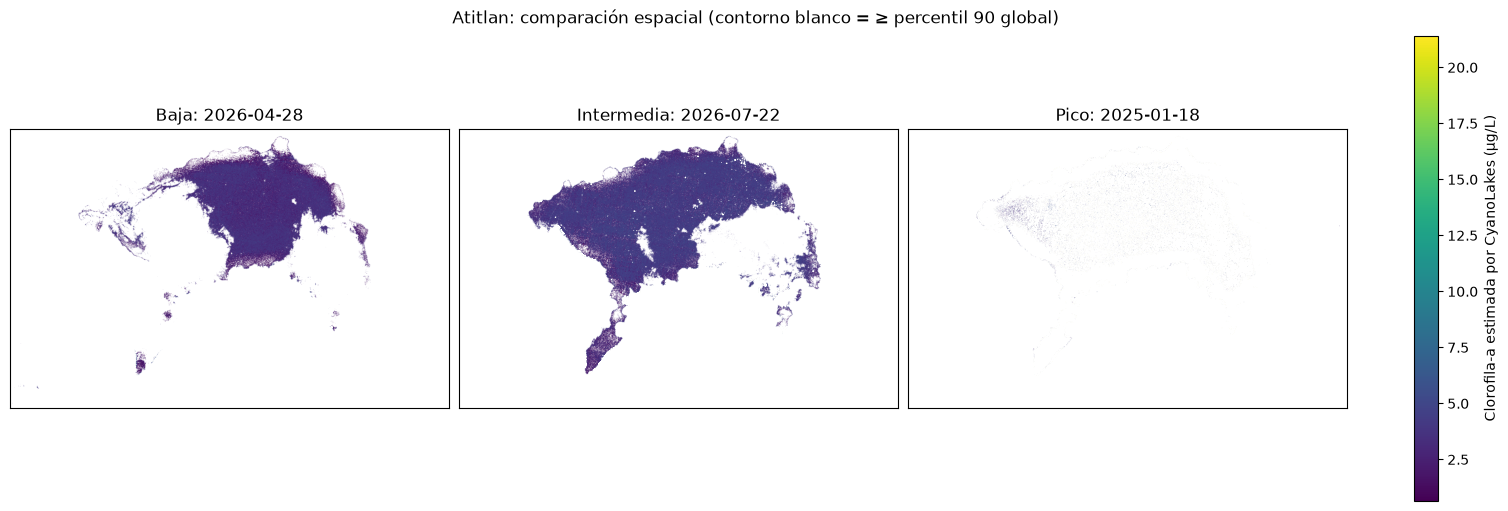

,lago,fecha,umbral_alto,pixeles_validos,pixeles_altos,porcentaje_area_alta
0,atitlan,2025-01-18,10.26716,88102,38080,43.222628
1,atitlan,2025-04-13,10.26716,871655,100,0.011472
2,atitlan,2025-05-13,10.26716,638307,217,0.033996
3,atitlan,2025-07-17,10.26716,781883,5521,0.706116
4,atitlan,2025-11-21,10.26716,562922,76919,13.664238
5,atitlan,2025-12-29,10.26716,649043,28078,4.326062
6,atitlan,2026-02-12,10.26716,659629,27518,4.171739
7,atitlan,2026-03-24,10.26716,1123907,492,0.043776
8,atitlan,2026-04-13,10.26716,158792,525,0.330621
9,atitlan,2026-04-28,10.26716,483325,72,0.014897


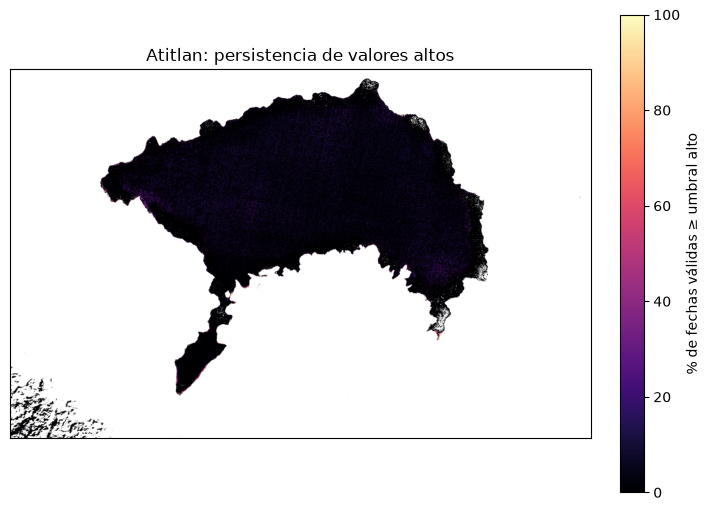

In [13]:
figures_dir = Path('outputs/figuras')
figures_dir.mkdir(parents=True, exist_ok=True)

if metricas is None:
    print('Análisis espacial pendiente: primero genere metricas_por_fecha.csv con los insumos validados.')
else:
    extension_partes, persistencias = [], {}
    try:
        stacks = [load_lake_stack(lago)[0] for lago in LAKES]
        umbral_alto = high_value_threshold(np.concatenate([item.ravel() for item in stacks]), percentile=90)
        print(f'Umbral alto reproducible (percentil 90 global): {umbral_alto:.2f} µg/L')

        for lago in LAKES:
            seleccion = select_comparison_dates(metricas, lago)
            display(seleccion[['categoria_comparacion', 'fecha', 'cianobacteria_promedio']])
            figura_mapas = plot_comparison_maps(lago, seleccion, umbral_alto)
            figura_mapas.savefig(figures_dir / f'{lago}_mapas_comparativos.png', dpi=180, bbox_inches='tight')
            plt.show()

            extension, capas_persistencia, _ = extent_and_persistence(lago, umbral_alto)
            extension_partes.append(extension)
            persistencias[lago] = capas_persistencia
            display(extension)
            figura_persistencia = plot_persistence(lago, capas_persistencia['persistencia'])
            figura_persistencia.savefig(figures_dir / f'{lago}_persistencia_valores_altos.png', dpi=180, bbox_inches='tight')
            plt.show()
    except (FileNotFoundError, ValueError) as error:
        extension_partes, persistencias = [], {}
        print(f'Análisis espacial no generado: {error}')
        print('Comparta data/raw/ y data/cyano/ completos para generar las figuras sin perder trazabilidad.')


### Resultados espaciales

El umbral alto común (percentil 90 global) fue **10.27 µg/L**. En Amatitlán, la fecha pico del promedio fue 2026-06-19 (63.97 µg/L) y el 97.10 % de sus píxeles válidos superó el umbral; esta lectura debe interpretarse con cautela porque todavía no se aplica un polígono vectorial preciso del lago. En Atitlán, el mayor promedio fue 2025-01-18 (43.93 µg/L) y el 43.22 % de los píxeles válidos superó el umbral.

Los mapas, la persistencia y las distribuciones respaldan estas comparaciones. Los máximos de enero de 2025 en Atitlán y junio de 2026 en Amatitlán requieren contraste con nubes, máscara de agua y datos de campo antes de atribuirles una causa ambiental.

## 7. Comparación entre lagos

La comparación integra las métricas temporales, espaciales y de frecuencia con reglas idénticas para ambos lagos. La intensidad se resume con el promedio y máximo por escena; la frecuencia, con las fechas críticas; y la extensión, con el porcentaje de píxeles válidos que supera el percentil 90 global. La persistencia muestra qué porcentaje de píxeles observados fue alto en al menos la mitad de sus fechas válidas.

In [ ]:
if metricas is None or not extension_partes:
    comparacion_lagos = None
    print('Comparación pendiente: se requieren las métricas y la extensión espacial de ambos lagos.')
else:
    extension_area_alta = pd.concat(extension_partes, ignore_index=True)
    comparacion_lagos = build_lake_comparison(metricas, extension_area_alta, persistencias)
    ruta_comparacion = save_lake_comparison(comparacion_lagos)
    display(comparacion_lagos)
    figura_comparacion = plot_lake_comparison(comparacion_lagos)
    figura_comparacion.savefig(figures_dir / 'comparacion_lagos.png', dpi=180, bbox_inches='tight')
    plt.show()
    print(f'Tabla de comparación guardada en: {ruta_comparacion.relative_to(PROJECT_ROOT)}')
    for resultado in comparacion_lagos.itertuples(index=False):
        print(
            f'{resultado.nombre_lago}: promedio entre escenas = {resultado.cianobacteria_promedio_escenas_ug_l:.2f} µg/L; '
            f'máximo = {resultado.cianobacteria_maxima_ug_l:.2f} µg/L ({resultado.fecha_maxima}); '
            f'área alta máxima = {resultado.area_alta_maxima_pct:.2f} %.')


### Interpretación comparativa

La tabla `comparacion_lagos` y la Figura de comparación sustentan la lectura entre lagos. Una diferencia en promedio, máximo o extensión alta describe la señal estimada de estas escenas, no una medición de campo ni una causalidad demostrada. Las diferencias podrían estar relacionadas con nutrientes, uso del suelo, presión urbana, temperatura, viento, mezcla y morfometría, pero esas son hipótesis que requieren datos auxiliares y muestreos de calidad de agua.

Al interpretar la frecuencia, el número de fechas críticas debe leerse junto con la intensidad y el porcentaje de área alta. La métrica de persistencia permite distinguir un valor alto aislado de zonas que se mantienen altas entre fechas válidas.

## 8. Análisis exploratorio adicional

La tabla siguiente cuantifica la proporción de área válida por encima del umbral alto. Los histogramas y boxplots permiten distinguir cambios en la distribución de píxeles de un cambio aislado en el promedio.

,lago,fecha,umbral_alto,pixeles_validos,pixeles_altos,porcentaje_area_alta
0,amatitlan,2025-01-28,10.26716,104762,65077,62.118898
1,amatitlan,2025-04-15,10.26716,48363,16286,33.674503
2,amatitlan,2025-04-28,10.26716,92362,29376,31.805288
3,amatitlan,2025-11-24,10.26716,114263,35427,31.004787
4,amatitlan,2026-01-08,10.26716,123144,98176,79.724550
5,amatitlan,2026-02-02,10.26716,9620,365,3.794179
6,amatitlan,2026-02-07,10.26716,39998,5553,13.883194
7,amatitlan,2026-03-29,10.26716,89925,51467,57.233250
8,amatitlan,2026-04-13,10.26716,137174,109194,79.602549
9,amatitlan,2026-04-28,10.26716,131987,68190,51.664179


Resumen de extensión actualizado.


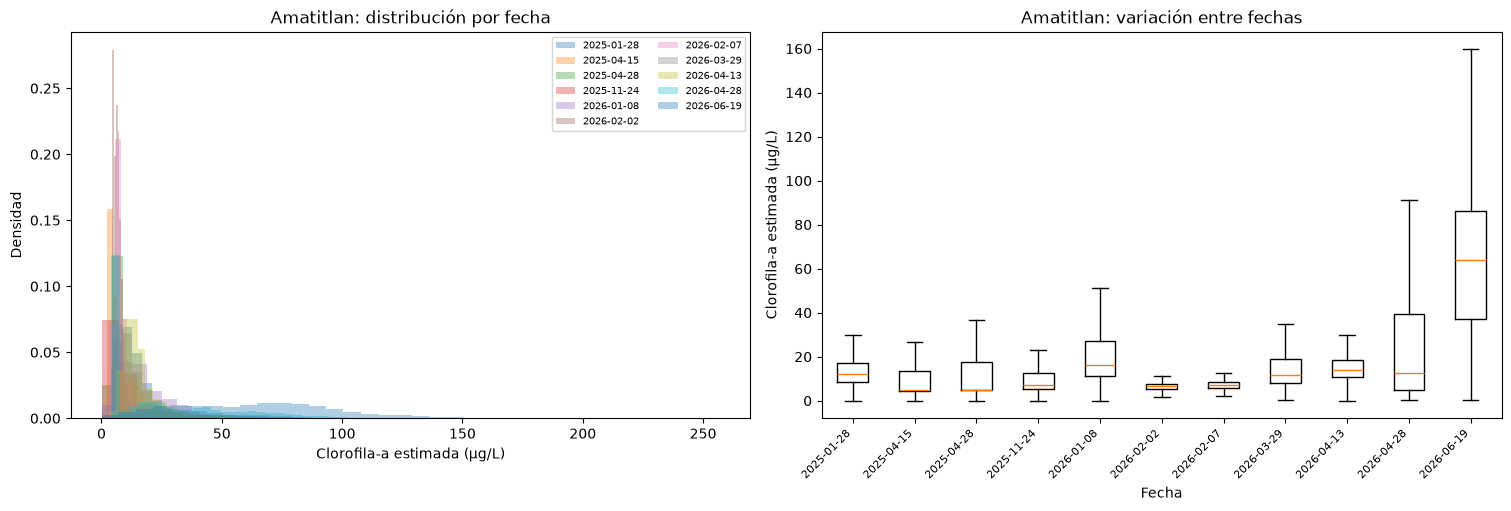

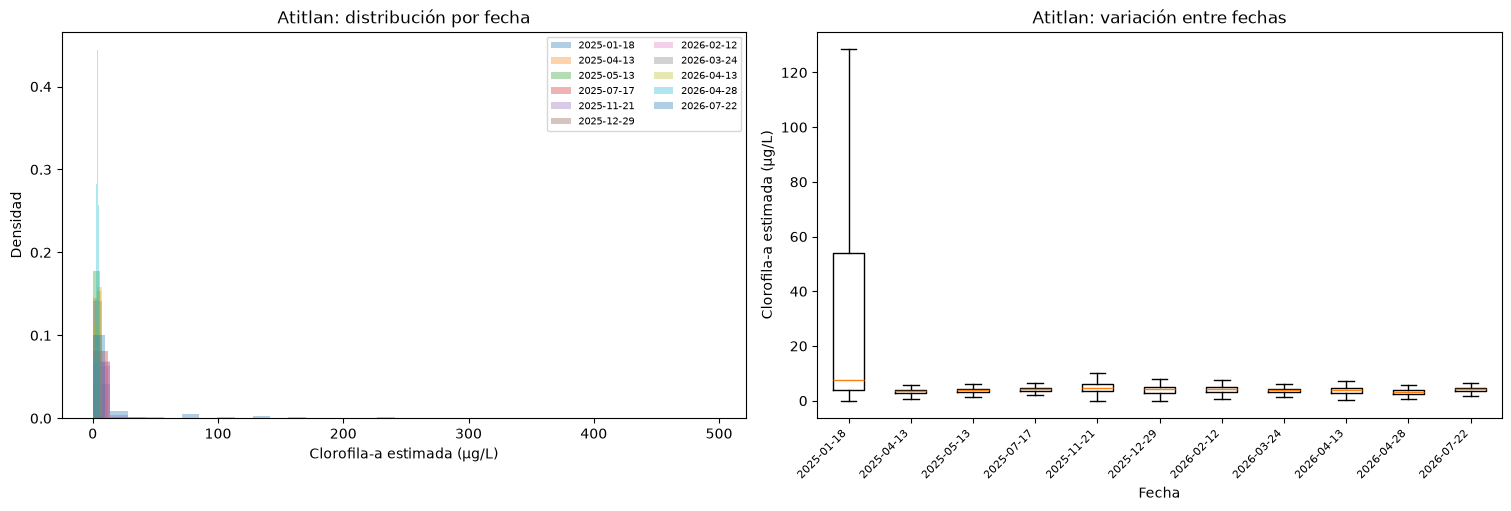

,lago,mes,n_fechas,cianobacteria_promedio_media,cianobacteria_promedio_mediana
0,amatitlan,1,2,18.355587,18.355587
1,amatitlan,2,2,7.294688,7.294688
2,amatitlan,3,1,17.142580,17.142580
3,amatitlan,4,4,16.035442,14.941013
4,amatitlan,6,1,63.971619,63.971619
5,amatitlan,11,1,13.280656,13.280656
6,atitlan,1,1,43.934631,43.934631
7,atitlan,2,1,5.397867,5.397867
8,atitlan,3,1,3.644007,3.644007
9,atitlan,4,3,3.308085,3.162546


El resumen mensual es descriptivo; la serie 2025--2026 no prueba estacionalidad ni causalidad climática.


In [14]:
if metricas is not None:
    resumen_mensual = monthly_summary(metricas)
    if extension_partes:
        extension_area_alta = pd.concat(extension_partes, ignore_index=True)
        save_spatial_tables(extension_area_alta, resumen_mensual)
        display(extension_area_alta)
        print('Resumen de extensión actualizado.')
        for lago in LAKES:
            figura_distribuciones = plot_distributions(lago)
            figura_distribuciones.savefig(figures_dir / f'{lago}_distribuciones_por_fecha.png', dpi=180, bbox_inches='tight')
            plt.show()
    else:
        print('Extensión, persistencia y distribuciones pendientes de los rasteres numéricos de cianobacteria.')
    display(resumen_mensual)
    Path('outputs/tablas').mkdir(parents=True, exist_ok=True)
    resumen_mensual.to_csv('outputs/tablas/resumen_mensual_cianobacteria.csv', index=False, encoding='utf-8-sig')
    print('El resumen mensual es descriptivo; la serie 2025--2026 no prueba estacionalidad ni causalidad climática.')


## Metodología y limitaciones

Se usan imágenes Sentinel-2 en las 11 fechas oficiales por lago. B04 y B08 permiten calcular NDVI; B03 y B08, NDWI. La estimación de cianobacteria se deriva del producto numérico documentado del algoritmo CyanoLakes, no de una interpretación visual de colores. Las métricas se calculan únicamente sobre píxeles válidos y la misma regla de máscara se aplica a todas las fechas. El umbral de valor alto es el percentil 90 global de los píxeles válidos de ambos lagos; por ello no cambia entre fechas ni entre lagos.

El inventario y la lista de control conservan la trazabilidad de cada imagen. La ausencia de una máscara vectorial precisa, nubes, cobertura parcial y la naturaleza indirecta de la estimación limitan las conclusiones. La serie 2025--2026 y las correlaciones por lago son exploratorias: no permiten inferir estacionalidad ni causalidad.


## Conclusiones

1. Las tablas de métricas, extensión y comparación integran las 22 fechas oficiales bajo definiciones consistentes de píxel válido, umbral alto y fecha crítica.

2. La intensidad y frecuencia de la señal se interpretan conjuntamente mediante `comparacion_lagos.csv`, los mapas comparativos y las gráficas temporales. La tabla identifica los máximos por lago, mientras que los mapas muestran si esos valores se concentran o cubren una fracción amplia de los píxeles válidos.

3. Las posibles diferencias entre Amatitlán y Atitlán deben presentarse como evidencia de esta estimación satelital y no como un diagnóstico definitivo de floración. La validación de campo y una máscara vectorial precisa son los siguientes pasos necesarios antes de orientar decisiones de manejo.